In [41]:
!pip install pandas numpy scikit-learn xgboost openpyxl

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

In [43]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'superstore_data.csv', 'Untitled.ipynb']


In [44]:
df = pd.read_csv("superstore_data.csv")
print(df.head())



      Id  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0   1826        1970  Graduation       Divorced  84835.0        0         0   
1      1        1961  Graduation         Single  57091.0        0         0   
2  10476        1958  Graduation        Married  67267.0        0         1   
3   1386        1967  Graduation       Together  32474.0        1         1   
4   5371        1989  Graduation         Single  21474.0        1         0   

  Dt_Customer  Recency  MntWines  ...  MntFishProducts  MntSweetProducts  \
0   6/16/2014        0       189  ...              111               189   
1   6/15/2014        0       464  ...                7                 0   
2   5/13/2014        0       134  ...               15                 2   
3   11/5/2014        0        10  ...                0                 0   
4    8/4/2014        0         6  ...               11                 0   

   MntGoldProds  NumDealsPurchases  NumWebPurchases  NumCatalogPurch

In [45]:
print(df.info())
print(df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [46]:
# Remove missing values
df = df.dropna()

# Clean column names
df.columns = df.columns.str.replace(" ", "_")

# Drop ID column if exists
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

In [47]:
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                          'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

df['Age'] = 2026 - df['Year_Birth']

df['Total_Purchases'] = df[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(axis=1)

df['Avg_Spending'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)

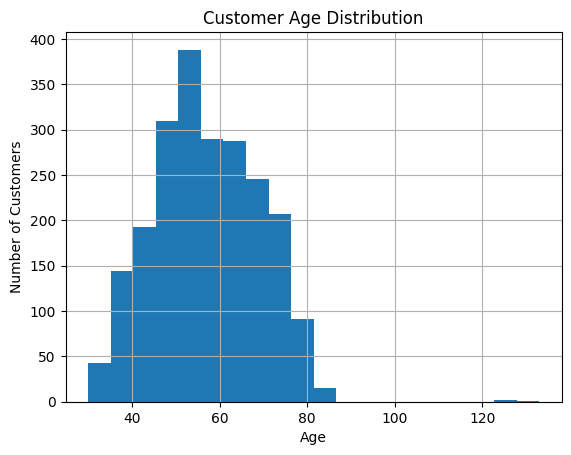

In [61]:
plt.figure()
plt.hist(df['Age'], bins=20)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.grid()
plt.show()

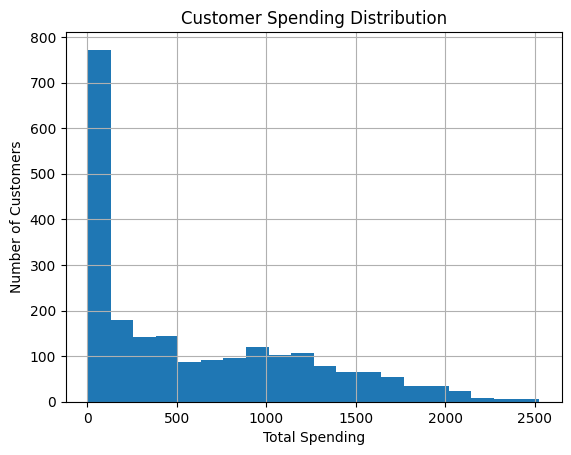

In [62]:
plt.figure()
plt.hist(df['Total_Spending'], bins=20)
plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.grid()
plt.show()

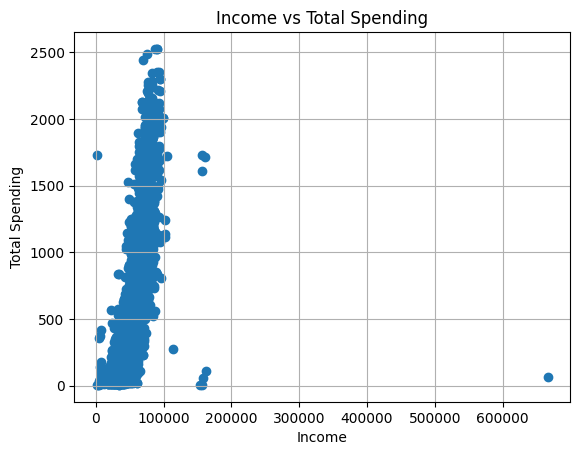

In [63]:
plt.figure()
plt.scatter(df['Income'], df['Total_Spending'])
plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.grid()
plt.show()

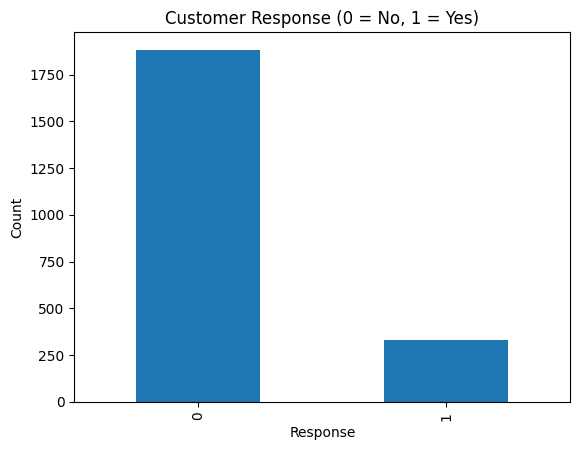

In [51]:
plt.figure()
df['Response'].value_counts().plot(kind='bar')
plt.title("Customer Response (0 = No, 1 = Yes)")
plt.xlabel("Response")
plt.ylabel("Count")
plt.show()

In [64]:
purchase_spending = df.groupby('Total_Purchases')['Total_Spending'].mean()

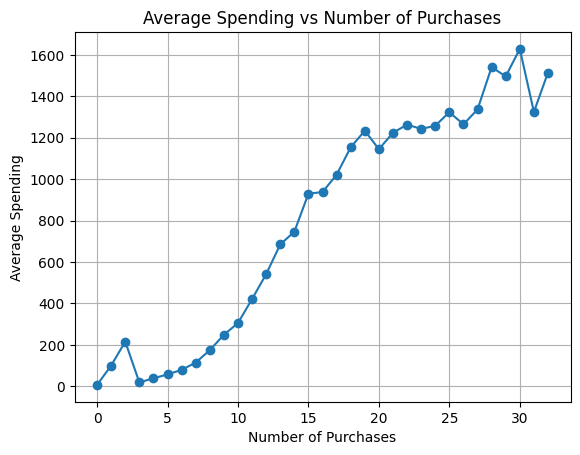

In [65]:
plt.figure()
plt.plot(purchase_spending.index, purchase_spending.values, marker='o')
plt.title("Average Spending vs Number of Purchases")
plt.xlabel("Number of Purchases")
plt.ylabel("Average Spending")
plt.grid()
plt.show()

In [53]:
df = pd.get_dummies(df, drop_first=True)

In [54]:
X = df.drop('Response', axis=1)
y = df['Response']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
from sklearn.model_selection import cross_val_score

cv_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss'
)

cv_scores = cross_val_score(cv_model, X, y, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.16666667 0.29119639 0.4221219  0.47404063 0.85327314]
Mean CV Accuracy: 0.44145974416854783


In [57]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [58]:
y_pred = model.predict(X_test)

In [59]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8671171171171171

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.95      0.92       379
           1       0.57      0.40      0.47        65

    accuracy                           0.87       444
   macro avg       0.73      0.67      0.70       444
weighted avg       0.85      0.87      0.86       444



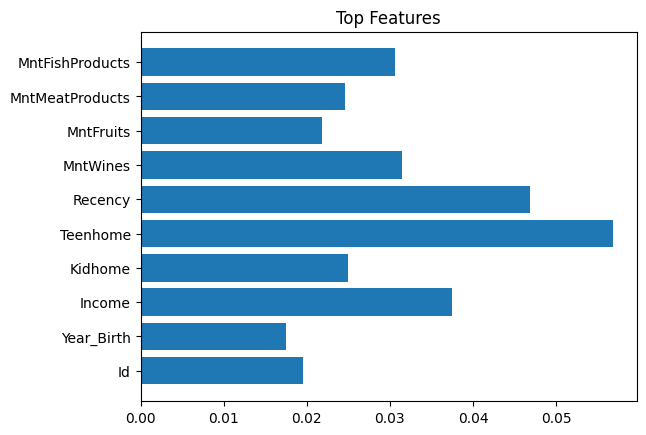

In [60]:
importance = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features[:10], importance[:10])
plt.title("Top Features")
plt.show()

In [69]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head(10))

      Actual  Predicted
955        0          0
219        0          1
1088       0          0
417        0          0
1647       0          0
535        0          0
1799       0          0
1706       0          0
988        0          0
970        0          0


In [70]:
new_customer = X_test.iloc[0:1]

prediction = model.predict(new_customer)[0]

print("Prediction (0 = No, 1 = Yes):", prediction)

Prediction (0 = No, 1 = Yes): 0


In [71]:
probability = model.predict_proba(new_customer)[0][1]

print("Probability of Response:", probability)

Probability of Response: 0.04056843


In [72]:
sample = X.iloc[0].copy()

sample['Income'] = 60000
sample['Total_Spending'] = 1500
sample['Total_Purchases'] = 20

sample = pd.DataFrame([sample])

prediction = model.predict(sample)[0]

print("Custom Prediction (0/1):", prediction)

Custom Prediction (0/1): 1
